### Predicting number of trips originated by a point using location only (via spatial interporation)
Spatial interpolation is a technique that allows to make prediction for the variable of interest for some points, starting from a set of points that may not contain the ones we are interested in. In this way we can predict the value of the target in a place were there is no measurement available. Many methods can be applied to perform spatial interpolation, starting from k-nn, which is one of the simplest.
K-Nearest Neighbors algorithm selects the nearest k observations to the desired point and computes the prediction for this location using a weighted average of these k neighbors.

Use numpy meshgrid to create a grid of location for which to make predictions. After the whole city is divided into a grid, we can use the coordinates within the considered area to make a geodataframe containing the cells of the grid where we would like to predict the value of the target.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from sklearn.neighbors import KNeighborsRegressor
from copy import deepcopy
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import mean_absolute_error, r2_score, explained_variance_score, mean_squared_error
import geohash as pgh
from sklearn import preprocessing

In [25]:
df = pd.read_parquet('C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet')
df = gpd.GeoDataFrame(df, crs='EPSG:4326', geometry=gpd.points_from_xy(df.trip_origin_longitude, df.trip_origin_latitude))

In [26]:
# extract bounding box of all locations in the dataset, 
# namely all the area of Trento where allowed e-scooters movements have been recorded
xmin, ymin, xmax, ymax = df.total_bounds
# produce all the longitude-latitude coordinates within the bounding box,
# with the final result of creating a grid in which the city is divided
x, y = np.meshgrid( np.linspace(xmin, xmax), np.linspace(ymin, ymax) )

In [27]:
# x and y are a matrix build as a list of lists 
# each list (row) identifying a set of coordinate (either lat or long) from west to east 
x

array([[11.099419  , 11.10027073, 11.10112247, ..., 11.13945053,
        11.14030227, 11.141154  ],
       [11.099419  , 11.10027073, 11.10112247, ..., 11.13945053,
        11.14030227, 11.141154  ],
       [11.099419  , 11.10027073, 11.10112247, ..., 11.13945053,
        11.14030227, 11.141154  ],
       ...,
       [11.099419  , 11.10027073, 11.10112247, ..., 11.13945053,
        11.14030227, 11.141154  ],
       [11.099419  , 11.10027073, 11.10112247, ..., 11.13945053,
        11.14030227, 11.141154  ],
       [11.099419  , 11.10027073, 11.10112247, ..., 11.13945053,
        11.14030227, 11.141154  ]])

In [28]:
# flatten x and y to make them a simple vector (list) 
grid = np.column_stack((x.flatten(), y.flatten()))
# convert flattened x and y to a geodataframe
grid_df = gpd.GeoDataFrame( geometry=gpd.points_from_xy(x=x.flatten(), y=y.flatten()) )

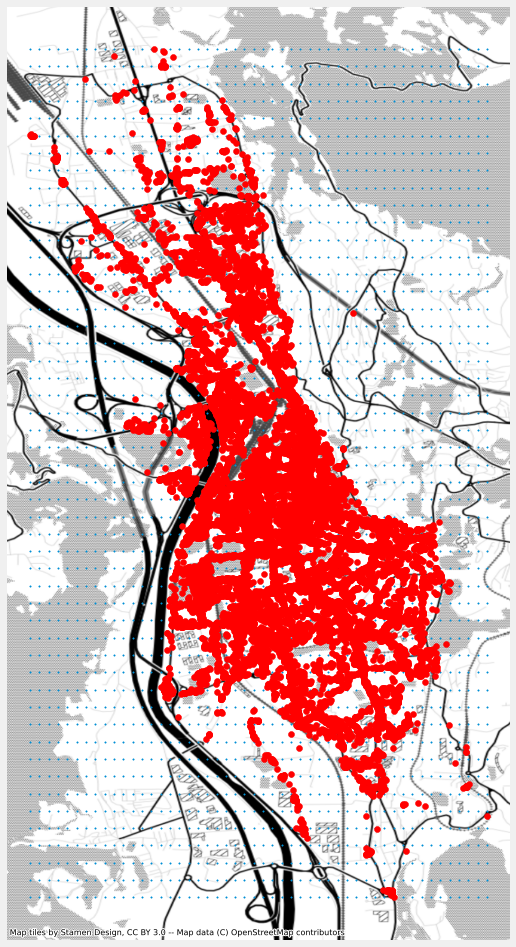

In [29]:
# plot all the points in the grid (blue points)
ax = grid_df.plot(markersize=2, figsize=(40,16)) 
# plot e-scooters observatios for starting points of trips
df.plot(ax=ax, color='red')
# basemap
ctx.add_basemap(
    ax, 
    crs=df.crs.to_string(), 
    source=ctx.providers.Stamen.TonerBackground
)
# remove axes
ax.set_axis_off()

In [84]:
df.head(2)

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,...,totalSnow_cm,windspeedKmph,tempC,visibility,precipMM,name_day,count_bus_multimodality,geohash_origin,holiday,geometry
0,BIT,3s1958,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,...,0.0,5,-1,10,0.0,friday,0.0,u0pyj4,False,POINT (11.12585 46.06906)
1,BIT,3s2628,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,...,0.0,5,-1,10,0.0,friday,0.0,u0pyj4,False,POINT (11.12385 46.06998)


In [79]:
d = deepcopy(df)
# round by 3 decimals to consider a "zone" around a point rather than a precise point
d['trip_origin_latitude'] = d['trip_origin_latitude'].round(3)
d['trip_origin_longitude'] = d['trip_origin_longitude'].round(3)
d = d.groupby(['trip_origin_latitude', 'trip_origin_longitude']).aggregate({'unique_id':['count']}).reset_index()
d.columns = d.columns.droplevel(1)
d.rename(columns = {'unique_id':'trips_count'}, inplace = True)
d = gpd.GeoDataFrame(d, crs='EPSG:4326', geometry=gpd.points_from_xy(d.trip_origin_longitude, d.trip_origin_latitude))

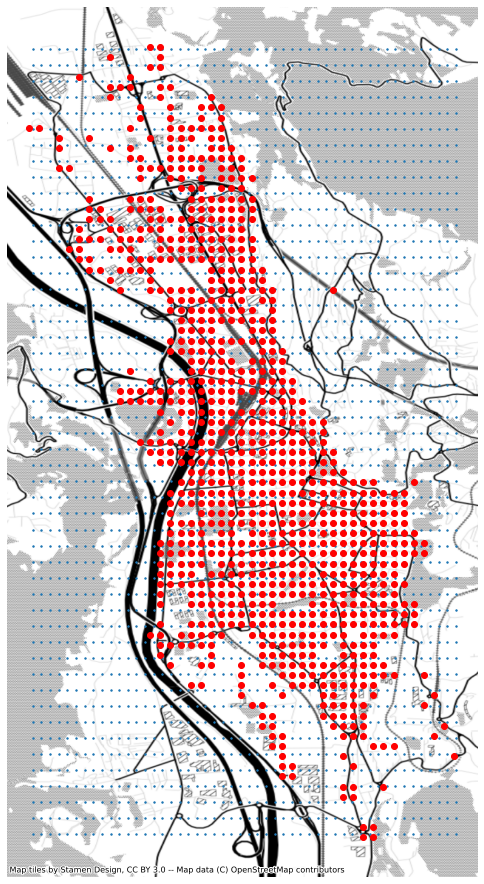

In [73]:
# plot all the points in the grid (blue points)
ax = grid_df.plot(markersize=2, figsize=(40,16)) 
# plot e-scooters observatios for starting points of trips
d.plot(ax=ax, color='red')
# basemap
ctx.add_basemap(
    ax, 
    crs=d.crs.to_string(), 
    source=ctx.providers.Stamen.TonerBackground
)
# remove axes
ax.set_axis_off()

In [245]:
d.trips_count.mean(), d.trips_count.median(), d.trips_count.min(), d.trips_count.max()

(88.24453694068679, 20.0, 1, 2748)

(0.0, 500.0)

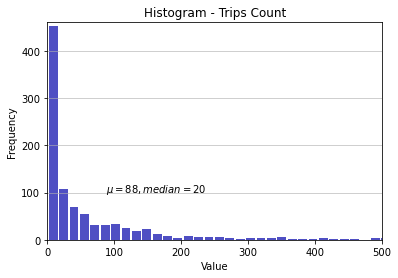

In [80]:
# trips count frequency (most locations have a low number of trips starting in there,
# but on average, 88 trips start from each data point, rounded by 3 decimals to consider
# a zone around a point rather than an exact point)

n, bins, patches = plt.hist(x=d.trips_count, bins='auto', color='#0504aa',
                            alpha=0.7, rwidth=0.85)

plt.grid(axis='y', alpha=0.75)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram - Trips Count')
plt.text(88, 100, r'$\mu=88,  median=20$')
maxfreq = n.max()

plt.ylim(ymax=np.ceil(maxfreq / 10) * 10 if maxfreq % 10 else maxfreq + 10)
plt.xlim(xmax=500, xmin=0)

In [81]:
start_pts = np.column_stack((d.geometry.x, d.geometry.y))
model = KNeighborsRegressor(n_neighbors=25, weights='distance').fit(start_pts, d.trips_count)

In [82]:
predictions = model.predict(grid)

In [83]:
predictions

array([12.00282173, 11.99786026,  9.72621218, ...,  7.33018919,
        7.32827992,  7.32642782])

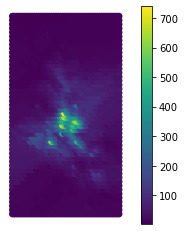

In [249]:
ax = grid_df.plot(predictions, legend=True)
ax.set_axis_off()

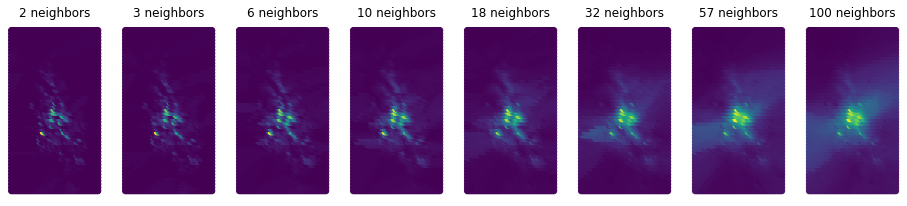

In [250]:
# try different values of k
f,ax = plt.subplots(1,8, figsize=(16,4))
for i,k_neighbors in enumerate(np.geomspace(2, 100, 8).astype(int)):
    facet = ax[i]
    # fit and predict
    predictions = KNeighborsRegressor(n_neighbors=k_neighbors, 
                    weights='distance').fit(start_pts, d.trips_count).predict(grid)
    grid_df.plot(predictions, ax=facet)
    facet.axis('off')
    facet.set_title(f"{k_neighbors} neighbors")